# 01c Traffic Detector Candidate v1

이 노트북은 01a/01b에서 얻은 관찰을 조합해서 **traffic light detector 후보 구조가 성립하는지** 확인하는 탐색 노트북이다.

아직 contract를 만들지 않는다. 여기서 하는 일은 다음 조합을 비교하는 것이다.

```text
HSV color profile
→ contour / bbox feature
→ contour size / compactness filter
→ loose spatial gate
→ frame-level candidate 여부
```

핵심 질문은 이것이다.

```text
색 + contour + 느슨한 위치/크기 조건을 합치면,
red/green traffic light를 안정적으로 후보화할 수 있는가?
```

## 01a / 01b와의 관계

지금까지의 흐름은 다음과 같다.

```text
01a: HSV threshold 후보가 색을 분리하는지 봄
01b: 그 mask에서 신호등 blob이 contour/bbox로 잡히는지 봄
01c: 색 + contour + spatial/size gate를 조합해 detector 후보를 비교
```

01a/01b 값은 아직 확정값이 아니다. 01c에서도 여러 후보를 비교한다.

이 노트북이 확정하지 않는 것:

- 최종 HSV threshold
- 최종 contour threshold
- 최종 ROI
- temporal voting
- event trigger 조건

이 노트북이 확인하는 것:

- green/red 각각 어떤 color profile이 안정적인지
- contour filter를 어느 정도 걸어도 target을 놓치지 않는지
- 오른쪽/상단 위치 gate를 넣으면 false positive가 줄어드는지
- 가까운 이벤트용 size gate를 너무 강하게 걸면 무엇을 놓치는지

## detector 후보를 평가하는 방법

정확한 bounding box GT가 없기 때문에, object detection mAP 같은 평가는 하지 않는다. 대신 frame 단위 proxy를 본다.

```text
target hit:
  green 이미지에서 green 후보가 1개 이상 생기는가?
  red 이미지에서 red 후보가 1개 이상 생기는가?

cross hit:
  red 이미지에서 green 후보가 생기는가?
  green 이미지에서 red 후보가 생기는가?
```

그리고 overlay로 후보 위치를 직접 확인한다. 숫자는 사람 검수의 보조 자료다.

In [1]:
from pathlib import Path
import os
import math
import random

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

random.seed(0)
np.random.seed(0)

EXP_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector")
DATASET_ROOT = Path(r"~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset")
TRAFFIC_RAW_ROOT = DATASET_ROOT / "traffic" / "raw"

OUT_01A = EXP_ROOT / "review_outputs" / "01a_traffic_hsv_mask_sweep_v1"
OUT_01B = EXP_ROOT / "review_outputs" / "01b_traffic_contour_probe_v1"
OUT_ROOT = EXP_ROOT / "review_outputs" / "01c_traffic_detector_candidate_v1"
TABLE_DIR = OUT_ROOT / "tables"
OVERLAY_DIR = OUT_ROOT / "overlays"
PLOT_DIR = OUT_ROOT / "plots"
NOTES_DIR = OUT_ROOT / "notes"
for d in [TABLE_DIR, OVERLAY_DIR, PLOT_DIR, NOTES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("EXP_ROOT:", EXP_ROOT)
print("TRAFFIC_RAW_ROOT:", TRAFFIC_RAW_ROOT)
print("OUT_ROOT:", OUT_ROOT)

EXP_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector
TRAFFIC_RAW_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\20_shared_assets\dataset\traffic\raw
OUT_ROOT: ~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1


## Windows 경로 / 이미지 helper

기존 18번 노트북들과 같은 방식으로 한글/긴 경로에서 안전하게 이미지를 읽고 쓴다.

In [2]:
def fs_path(path):
    path = Path(path)
    s = str(path.resolve())
    long_prefix = "\\\\?\\"
    if os.name == "nt" and not s.startswith(long_prefix):
        return long_prefix + s
    return s


def exists_fs(path):
    return os.path.exists(fs_path(path))


def imread_bgr(path):
    path = Path(path)
    data = np.fromfile(fs_path(path), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"cv2.imdecode failed: {path}")
    return img


def imwrite_bgr(path, bgr):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    ext = path.suffix if path.suffix else ".jpg"
    ok, buf = cv2.imencode(ext, bgr)
    if not ok:
        raise RuntimeError(f"cv2.imencode failed: {path}")
    buf.tofile(fs_path(path))
    return path


def show_saved_image(path, width=None):
    path = Path(path)
    with open(fs_path(path), "rb") as f:
        data = f.read()
    display(Image(data=data, width=width))


def put_text(img, text, org=(8, 24), scale=0.62, color=(255, 255, 255), thickness=2):
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, (0, 0, 0), thickness + 2, cv2.LINE_AA)
    cv2.putText(img, text, org, cv2.FONT_HERSHEY_SIMPLEX, scale, color, thickness, cv2.LINE_AA)

## 데이터 로드

01a의 sample record를 기본 입력으로 사용한다.

- `stat_df`: profile 비교용 80 green + 80 red 샘플
- `vis_df`: overlay로 보기 좋은 대표 샘플
- `stress_df`: 사용자가 지목한 저조도/스트레스 샘플

In [3]:
def iter_images(root):
    root = Path(root)
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    if not exists_fs(root):
        return []
    return sorted([p for p in root.rglob("*") if p.suffix.lower() in exts])


def build_traffic_index():
    rows = []
    for label in ["green", "red"]:
        for path in iter_images(TRAFFIC_RAW_ROOT / label):
            rows.append({"label": label, "path": str(path), "filename": path.name, "stem": path.stem})
    return pd.DataFrame(rows)

index_csv = OUT_01A / "tables" / "traffic_dataset_index.csv"
visual_csv = OUT_01A / "tables" / "traffic_hsv_sweep_visual_sample_records.csv"
stat_csv = OUT_01A / "tables" / "traffic_hsv_sweep_stat_sample_records.csv"
stress_csv = OUT_01A / "tables" / "traffic_manual_stress_sample_records.csv"

traffic_df = pd.read_csv(index_csv) if exists_fs(index_csv) else build_traffic_index()
vis_df = pd.read_csv(visual_csv) if exists_fs(visual_csv) else traffic_df.groupby("label", group_keys=False).sample(n=8, random_state=0)
stat_df = pd.read_csv(stat_csv) if exists_fs(stat_csv) else traffic_df.groupby("label", group_keys=False).sample(n=min(80, len(traffic_df)), random_state=1)
stress_df = pd.read_csv(stress_csv) if exists_fs(stress_csv) else pd.DataFrame(columns=traffic_df.columns)

for df in [traffic_df, vis_df, stat_df, stress_df]:
    if len(df) and "path" in df.columns:
        df["path"] = df["path"].astype(str)

print("traffic_df", traffic_df.groupby("label").size().to_dict())
print("stat_df", stat_df.groupby("label").size().to_dict())
print("vis_df", vis_df.groupby("label").size().to_dict())
print("stress_df", stress_df.groupby("label").size().to_dict() if len(stress_df) else {})
display(stat_df.head())

traffic_df {'green': 313, 'red': 343}
stat_df {'green': 80, 'red': 80}
vis_df {'green': 8, 'red': 8}
stress_df {'green': 8, 'red': 8}


,label,path,filename,rel_path
0,green,~\02_Projects\University\26-1_Em...,20260430_174929_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174929_signs_green_...
1,green,~\02_Projects\University\26-1_Em...,20260430_174945_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174945_signs_green_...
2,green,~\02_Projects\University\26-1_Em...,20260430_174910_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174910_signs_green_...
3,green,~\02_Projects\University\26-1_Em...,20260501_123333_07_traffic_capture_green_01853...,traffic\raw\green\20260501_123333_07_traffic_c...
4,green,~\02_Projects\University\26-1_Em...,20260430_174919_signs_green_moving_mixed_right...,traffic\raw\green\20260430_174919_signs_green_...


## color profile 후보

01a/01b에서 보인 후보를 그대로 사용하되, 이름을 detector profile에서 읽기 쉽게 바꾼다.

- `green_balanced`: target을 거의 놓치지 않는 기본 초록 후보
- `green_strict`: 더 보수적인 초록 후보
- `red_balanced`: target을 거의 놓치지 않는 기본 빨강 후보
- `red_strict`: 더 보수적인 빨강 후보

이 이름은 편의를 위한 것이고 최종 contract 이름이 아니다.

In [4]:
COLOR_PROFILES = [
    {"color_profile": "green_balanced", "target": "green", "source": "green_core_s160_v150", "h_ranges": [(65, 95)], "s_min": 160, "v_min": 150, "color_bgr": (40, 255, 40)},
    {"color_profile": "green_strict", "target": "green", "source": "green_tight_s170_v160", "h_ranges": [(70, 92)], "s_min": 170, "v_min": 160, "color_bgr": (40, 255, 40)},
    {"color_profile": "red_balanced", "target": "red", "source": "red_core_s140_v140", "h_ranges": [(0, 10), (170, 179)], "s_min": 140, "v_min": 140, "color_bgr": (40, 40, 255)},
    {"color_profile": "red_strict", "target": "red", "source": "red_core_s160_v150", "h_ranges": [(0, 10), (172, 179)], "s_min": 160, "v_min": 150, "color_bgr": (40, 40, 255)},
]

pd.DataFrame([{k: (str(v) if k == "h_ranges" else v) for k, v in p.items() if k != "color_bgr"} for p in COLOR_PROFILES]).to_csv(
    TABLE_DIR / "traffic_color_profiles.csv", index=False, encoding="utf-8-sig"
)
display(pd.DataFrame([{k: (str(v) if k == "h_ranges" else v) for k, v in p.items() if k != "color_bgr"} for p in COLOR_PROFILES]))

,color_profile,target,source,h_ranges,s_min,v_min
0,green_balanced,green,green_core_s160_v150,"[(65, 95)]",160,150
1,green_strict,green,green_tight_s170_v160,"[(70, 92)]",170,160
2,red_balanced,red,red_core_s140_v140,"[(0, 10), (170, 179)]",140,140
3,red_strict,red,red_core_s160_v150,"[(0, 10), (172, 179)]",160,150


## contour filter / spatial gate 후보

01c의 핵심은 여기다. 하나의 값을 확정하지 않고, 여러 수준을 비교한다.

Contour filter:

- `compact_loose`: 아주 작은 노이즈만 제거한다.
- `event_balanced`: 신호등 이벤트 후보로 볼 만한 크기를 요구한다. green/red 크기 차이를 반영한다.
- `near_event_strict`: 가까운 신호등만 남긴다. 놓치는 프레임이 늘어날 수 있다.

Spatial gate:

- `none`: 위치 사전지식 없음.
- `right_half`: 화면 오른쪽에 있는 후보만.
- `right_upper`: 화면 오른쪽 + 너무 아래쪽이 아닌 후보만.
- `event_region`: 더 좁은 이벤트 예상 영역. 아직 확정 ROI가 아니다.

In [5]:
CONTOUR_FILTERS = [
    {
        "contour_filter": "compact_loose",
        "desc": "tiny noise removal only",
        "min_area_by_target": {"green": 20.0, "red": 20.0},
        "min_bbox_w_by_target": {"green": 5, "red": 5},
        "min_bbox_h_by_target": {"green": 5, "red": 5},
        "aspect_min": 0.35,
        "aspect_max": 3.50,
        "fill_min": 0.04,
    },
    {
        "contour_filter": "event_balanced",
        "desc": "usable event candidate; green/red have different expected blob size",
        "min_area_by_target": {"green": 500.0, "red": 80.0},
        "min_bbox_w_by_target": {"green": 18, "red": 8},
        "min_bbox_h_by_target": {"green": 22, "red": 10},
        "aspect_min": 0.35,
        "aspect_max": 3.50,
        "fill_min": 0.04,
    },
    {
        "contour_filter": "near_event_strict",
        "desc": "near/large traffic light candidate only",
        "min_area_by_target": {"green": 1500.0, "red": 200.0},
        "min_bbox_w_by_target": {"green": 35, "red": 14},
        "min_bbox_h_by_target": {"green": 40, "red": 16},
        "aspect_min": 0.35,
        "aspect_max": 3.50,
        "fill_min": 0.04,
    },
]

SPATIAL_GATES = [
    {"spatial_gate": "none", "desc": "no spatial prior", "x_min": 0.0, "x_max": 1.0, "y_min": 0.0, "y_max": 1.0},
    {"spatial_gate": "right_half", "desc": "right-side prior only", "x_min": 0.55, "x_max": 1.0, "y_min": 0.0, "y_max": 1.0},
    {"spatial_gate": "right_upper", "desc": "right and not lower frame", "x_min": 0.55, "x_max": 1.0, "y_min": 0.0, "y_max": 0.60},
    {"spatial_gate": "event_region", "desc": "narrower candidate event region, not final ROI", "x_min": 0.60, "x_max": 1.0, "y_min": 0.0, "y_max": 0.58},
]

pd.DataFrame(CONTOUR_FILTERS).to_csv(TABLE_DIR / "traffic_contour_filter_profiles.csv", index=False, encoding="utf-8-sig")
pd.DataFrame(SPATIAL_GATES).to_csv(TABLE_DIR / "traffic_spatial_gate_profiles.csv", index=False, encoding="utf-8-sig")
display(pd.DataFrame(CONTOUR_FILTERS))
display(pd.DataFrame(SPATIAL_GATES))

,contour_filter,desc,min_area_by_target,min_bbox_w_by_target,min_bbox_h_by_target,aspect_min,aspect_max,fill_min
0,compact_loose,tiny noise removal only,"{'green': 20.0, 'red': 20.0}","{'green': 5, 'red': 5}","{'green': 5, 'red': 5}",0.35,3.5,0.04
1,event_balanced,usable event candidate; green/red have differe...,"{'green': 500.0, 'red': 80.0}","{'green': 18, 'red': 8}","{'green': 22, 'red': 10}",0.35,3.5,0.04
2,near_event_strict,near/large traffic light candidate only,"{'green': 1500.0, 'red': 200.0}","{'green': 35, 'red': 14}","{'green': 40, 'red': 16}",0.35,3.5,0.04


,spatial_gate,desc,x_min,x_max,y_min,y_max
0,none,no spatial prior,0.00,1.0,0.0,1.00
1,right_half,right-side prior only,0.55,1.0,0.0,1.00
2,right_upper,right and not lower frame,0.55,1.0,0.0,0.60
3,event_region,"narrower candidate event region, not final ROI",0.60,1.0,0.0,0.58


## mask / contour / filter 함수

아래 코드는 detector 후보 평가를 위한 공통 함수다. 여기서도 아직 최종 detector 로직을 확정하지 않는다.

In [6]:
def hsv_mask_from_profile(bgr, profile):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h, s, v = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]
    mask = np.zeros(h.shape, dtype=np.uint8)
    for lo, hi in profile["h_ranges"]:
        h_ok = ((h >= lo) & (h <= hi)) if lo <= hi else ((h >= lo) | (h <= hi))
        ok = h_ok & (s >= profile["s_min"]) & (v >= profile["v_min"])
        mask[ok] = 255
    return mask


def extract_contour_features(mask):
    found = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = found[0] if len(found) == 2 else found[1]
    h_img, w_img = mask.shape[:2]
    rows = []
    kept = []
    for cnt in contours:
        area = float(cv2.contourArea(cnt))
        if area < 1.0:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        perim = float(cv2.arcLength(cnt, True))
        bbox_area = float(w * h)
        row = {
            "area_px": area,
            "perimeter_px": perim,
            "bbox_x": int(x),
            "bbox_y": int(y),
            "bbox_w": int(w),
            "bbox_h": int(h),
            "bbox_area_px": bbox_area,
            "aspect_ratio": float(w) / float(h) if h > 0 else math.nan,
            "fill_ratio": area / bbox_area if bbox_area > 0 else math.nan,
            "circularity": (4.0 * math.pi * area / (perim * perim)) if perim > 0 else math.nan,
            "center_x": x + w / 2.0,
            "center_y": y + h / 2.0,
            "center_x_norm": (x + w / 2.0) / float(w_img),
            "center_y_norm": (y + h / 2.0) / float(h_img),
        }
        rows.append(row)
        kept.append(cnt)
    order = np.argsort([-r["area_px"] for r in rows]).tolist() if rows else []
    rows = [rows[i] for i in order]
    kept = [kept[i] for i in order]
    for rank, row in enumerate(rows, start=1):
        row["rank_area"] = rank
    return rows, kept


def contour_passes(row, target, contour_filter, spatial_gate):
    if not np.isfinite(row.get("area_px", np.nan)):
        return False
    min_area = contour_filter["min_area_by_target"][target]
    min_w = contour_filter["min_bbox_w_by_target"][target]
    min_h = contour_filter["min_bbox_h_by_target"][target]
    if row["area_px"] < min_area:
        return False
    if row["bbox_w"] < min_w or row["bbox_h"] < min_h:
        return False
    if not (contour_filter["aspect_min"] <= row["aspect_ratio"] <= contour_filter["aspect_max"]):
        return False
    if row["fill_ratio"] < contour_filter["fill_min"]:
        return False
    if not (spatial_gate["x_min"] <= row["center_x_norm"] <= spatial_gate["x_max"]):
        return False
    if not (spatial_gate["y_min"] <= row["center_y_norm"] <= spatial_gate["y_max"]):
        return False
    return True


def score_candidate(row):
    # 탐색용 정렬 점수다. 최종 contract 점수가 아니다.
    return float(row["area_px"]) + 250.0 * float(row["fill_ratio"]) - 20.0 * abs(float(row["aspect_ratio"]) - 1.0)

## detector candidate 실행

모든 조합을 돌린다.

```text
4 color profiles × 3 contour filters × 4 spatial gates
```

각 frame에서 통과한 contour가 1개 이상 있으면 frame-level candidate hit으로 기록한다.

In [7]:
def run_detector_candidate_on_record(record, color_profile, contour_filter, spatial_gate):
    bgr = imread_bgr(record["path"])
    mask = hsv_mask_from_profile(bgr, color_profile)
    rows, contours = extract_contour_features(mask)
    passed = []
    passed_contours = []
    for row, cnt in zip(rows, contours):
        if contour_passes(row, color_profile["target"], contour_filter, spatial_gate):
            r = dict(row)
            r["score"] = score_candidate(row)
            passed.append(r)
            passed_contours.append(cnt)
    order = np.argsort([-r["score"] for r in passed]).tolist() if passed else []
    passed = [passed[i] for i in order]
    passed_contours = [passed_contours[i] for i in order]
    return mask, rows, contours, passed, passed_contours

frame_rows = []
passed_rows = []
records = stat_df.to_dict("records")

for color_profile in COLOR_PROFILES:
    for contour_filter in CONTOUR_FILTERS:
        for spatial_gate in SPATIAL_GATES:
            detector_name = f"{color_profile['color_profile']}__{contour_filter['contour_filter']}__{spatial_gate['spatial_gate']}"
            for rec in records:
                mask, all_rows, all_contours, passed, passed_contours = run_detector_candidate_on_record(rec, color_profile, contour_filter, spatial_gate)
                is_target_label = rec["label"] == color_profile["target"]
                frame_rows.append({
                    "detector_name": detector_name,
                    "color_profile": color_profile["color_profile"],
                    "source_color_candidate": color_profile["source"],
                    "target": color_profile["target"],
                    "contour_filter": contour_filter["contour_filter"],
                    "spatial_gate": spatial_gate["spatial_gate"],
                    "label": rec["label"],
                    "is_target_label": is_target_label,
                    "filename": rec.get("filename", Path(rec["path"]).name),
                    "path": rec["path"],
                    "raw_contour_count": len(all_rows),
                    "passed_count": len(passed),
                    "hit": len(passed) > 0,
                    "top_area_px": passed[0]["area_px"] if passed else np.nan,
                    "top_bbox_w": passed[0]["bbox_w"] if passed else np.nan,
                    "top_bbox_h": passed[0]["bbox_h"] if passed else np.nan,
                    "top_center_x_norm": passed[0]["center_x_norm"] if passed else np.nan,
                    "top_center_y_norm": passed[0]["center_y_norm"] if passed else np.nan,
                    "top_score": passed[0]["score"] if passed else np.nan,
                })
                for rank, row in enumerate(passed[:5], start=1):
                    out = dict(frame_rows[-1])
                    out.update({f"candidate_{k}": v for k, v in row.items()})
                    out["passed_rank"] = rank
                    passed_rows.append(out)

frame_df = pd.DataFrame(frame_rows)
passed_df = pd.DataFrame(passed_rows)
frame_df.to_csv(TABLE_DIR / "traffic_detector_candidate_frame_results.csv", index=False, encoding="utf-8-sig")
passed_df.to_csv(TABLE_DIR / "traffic_detector_candidate_passed_contours.csv", index=False, encoding="utf-8-sig")

print("frame rows", len(frame_df), "passed rows", len(passed_df))
display(frame_df.head())

frame rows 7680 passed rows 3201


,detector_name,color_profile,source_color_candidate,target,contour_filter,spatial_gate,label,is_target_label,filename,path,raw_contour_count,passed_count,hit,top_area_px,top_bbox_w,top_bbox_h,top_center_x_norm,top_center_y_norm,top_score
0,green_balanced__compact_loose__none,green_balanced,green_core_s160_v150,green,compact_loose,none,green,True,20260430_174929_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,2,2,True,110.0,26.0,28.0,0.762346,0.306584,146.346154
1,green_balanced__compact_loose__none,green_balanced,green_core_s160_v150,green,compact_loose,none,green,True,20260430_174945_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,3,2,True,1033.5,47.0,54.0,0.799769,0.248971,1132.710008
2,green_balanced__compact_loose__none,green_balanced,green_core_s160_v150,green,compact_loose,none,green,True,20260430_174910_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,4,3,True,842.5,34.0,36.0,0.688272,0.301440,1013.468137
3,green_balanced__compact_loose__none,green_balanced,green_core_s160_v150,green,compact_loose,none,green,True,20260501_123333_07_traffic_capture_green_01853...,~\02_Projects\University\26-1_Em...,1,1,True,4054.5,72.0,80.0,0.800926,0.235597,4228.476562
4,green_balanced__compact_loose__none,green_balanced,green_core_s160_v150,green,compact_loose,none,green,True,20260430_174919_signs_green_moving_mixed_right...,~\02_Projects\University\26-1_Em...,2,2,True,1813.5,59.0,69.0,0.920139,0.209362,1921.968435


## frame-level 요약

`target_hit_pct`는 target label에서 후보가 잡힌 비율이다.

`cross_hit_pct`는 반대 label에서 잘못 후보가 생긴 비율이다.

이 값만으로 확정하지 않는다. overlay에서 후보 위치가 실제 신호등인지 반드시 확인한다.

In [8]:
summary_rows = []
for detector_name, g in frame_df.groupby("detector_name"):
    first = g.iloc[0]
    target = first["target"]
    target_g = g[g["label"] == target]
    cross_g = g[g["label"] != target]
    summary_rows.append({
        "detector_name": detector_name,
        "target": target,
        "color_profile": first["color_profile"],
        "source_color_candidate": first["source_color_candidate"],
        "contour_filter": first["contour_filter"],
        "spatial_gate": first["spatial_gate"],
        "target_frames": len(target_g),
        "target_hit_pct": float(target_g["hit"].mean() * 100.0) if len(target_g) else np.nan,
        "cross_frames": len(cross_g),
        "cross_hit_pct": float(cross_g["hit"].mean() * 100.0) if len(cross_g) else np.nan,
        "target_passed_count_median": float(target_g["passed_count"].median()) if len(target_g) else np.nan,
        "cross_passed_count_median": float(cross_g["passed_count"].median()) if len(cross_g) else np.nan,
        "target_top_area_median": float(target_g["top_area_px"].median()) if target_g["top_area_px"].notna().any() else np.nan,
        "target_top_bbox_h_median": float(target_g["top_bbox_h"].median()) if target_g["top_bbox_h"].notna().any() else np.nan,
        "target_top_center_x_median": float(target_g["top_center_x_norm"].median()) if target_g["top_center_x_norm"].notna().any() else np.nan,
        "target_top_center_y_median": float(target_g["top_center_y_norm"].median()) if target_g["top_center_y_norm"].notna().any() else np.nan,
    })

summary_df = pd.DataFrame(summary_rows).sort_values(["target", "cross_hit_pct", "target_hit_pct"], ascending=[True, True, False])
summary_df.to_csv(TABLE_DIR / "traffic_detector_candidate_summary.csv", index=False, encoding="utf-8-sig")

display(summary_df)

,detector_name,target,color_profile,source_color_candidate,contour_filter,spatial_gate,target_frames,target_hit_pct,cross_frames,cross_hit_pct,target_passed_count_median,cross_passed_count_median,target_top_area_median,target_top_bbox_h_median,target_top_center_x_median,target_top_center_y_median
1,green_balanced__compact_loose__none,green,green_balanced,green_core_s160_v150,compact_loose,none,80,100.00,80,0.0,1.0,0.0,2808.50,72.5,0.779321,0.218107
0,green_balanced__compact_loose__event_region,green,green_balanced,green_core_s160_v150,compact_loose,event_region,80,98.75,80,0.0,1.0,0.0,2817.50,73.0,0.779707,0.217593
2,green_balanced__compact_loose__right_half,green,green_balanced,green_core_s160_v150,compact_loose,right_half,80,98.75,80,0.0,1.0,0.0,2817.50,73.0,0.779707,0.217593
3,green_balanced__compact_loose__right_upper,green,green_balanced,green_core_s160_v150,compact_loose,right_upper,80,98.75,80,0.0,1.0,0.0,2817.50,73.0,0.779707,0.217593
5,green_balanced__event_balanced__none,green,green_balanced,green_core_s160_v150,event_balanced,none,80,93.75,80,0.0,1.0,0.0,2859.50,74.0,0.778935,0.215535
4,green_balanced__event_balanced__event_region,green,green_balanced,green_core_s160_v150,event_balanced,event_region,80,92.50,80,0.0,1.0,0.0,2879.00,74.5,0.778935,0.215535
6,green_balanced__event_balanced__right_half,green,green_balanced,green_core_s160_v150,event_balanced,right_half,80,92.50,80,0.0,1.0,0.0,2879.00,74.5,0.778935,0.215535
7,green_balanced__event_balanced__right_upper,green,green_balanced,green_core_s160_v150,event_balanced,right_upper,80,92.50,80,0.0,1.0,0.0,2879.00,74.5,0.778935,0.215535
13,green_strict__compact_loose__none,green,green_strict,green_tight_s170_v160,compact_loose,none,80,92.50,80,0.0,1.0,0.0,2262.00,69.5,0.774306,0.216049
12,green_strict__compact_loose__event_region,green,green_strict,green_tight_s170_v160,compact_loose,event_region,80,91.25,80,0.0,1.0,0.0,2368.00,71.0,0.778164,0.216049


## 후보 조합 heatmap

다음 그림은 profile별 target hit와 cross hit을 빠르게 비교하기 위한 것이다.

- target hit은 높을수록 좋다.
- cross hit은 낮을수록 좋다.

단, `near_event_strict`는 일부러 가까운 이벤트만 남기는 profile이라 target hit이 낮을 수 있다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\plots\traffic_green_target_hit_pct_heatmap.png


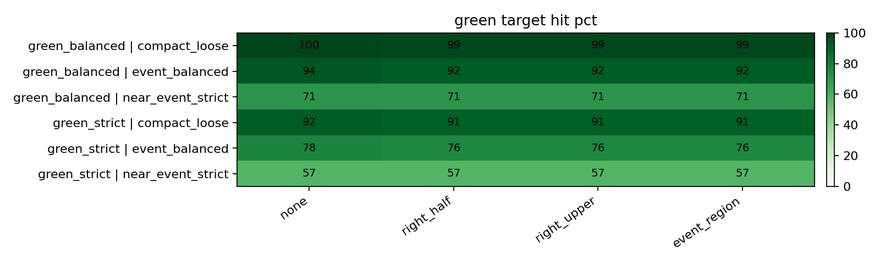

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\plots\traffic_green_cross_hit_pct_heatmap.png


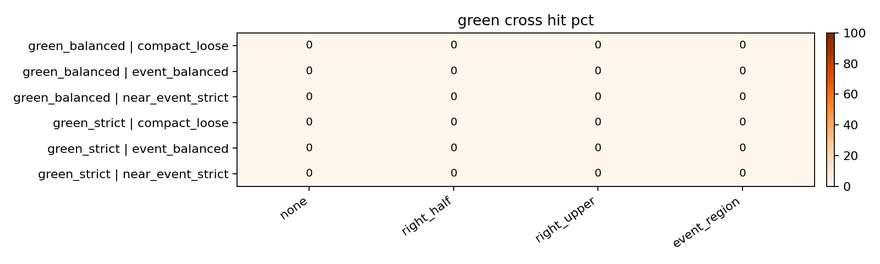

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\plots\traffic_red_target_hit_pct_heatmap.png


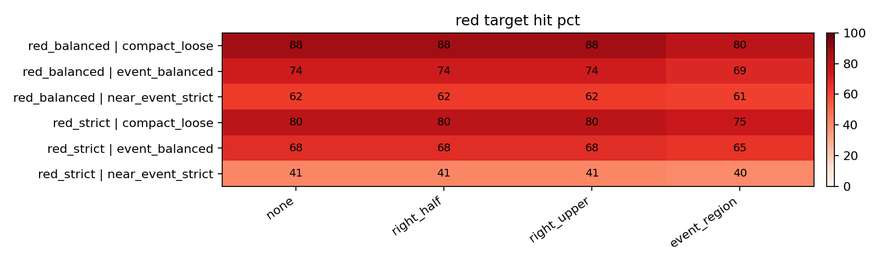

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\plots\traffic_red_cross_hit_pct_heatmap.png


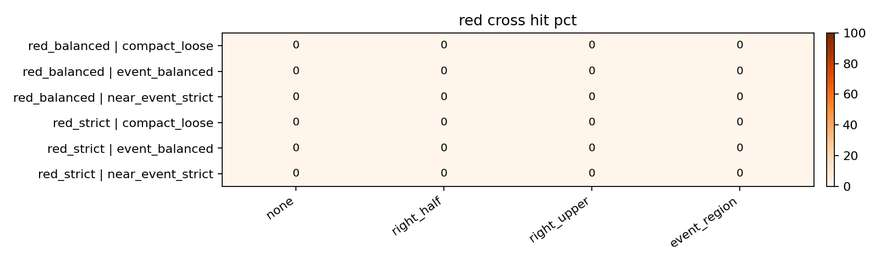

In [9]:
def make_heatmap_for_target(target):
    sub = summary_df[summary_df["target"] == target].copy()
    sub["profile_key"] = sub["color_profile"] + " | " + sub["contour_filter"]
    for metric, title, cmap in [
        ("target_hit_pct", f"{target} target hit pct", "Greens" if target == "green" else "Reds"),
        ("cross_hit_pct", f"{target} cross hit pct", "Oranges"),
    ]:
        pivot = sub.pivot_table(index="profile_key", columns="spatial_gate", values=metric, aggfunc="mean")
        pivot = pivot[[g["spatial_gate"] for g in SPATIAL_GATES if g["spatial_gate"] in pivot.columns]]
        fig, ax = plt.subplots(figsize=(10, max(3, 0.48 * len(pivot))))
        im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap=cmap, vmin=0, vmax=100)
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels(pivot.columns, rotation=35, ha="right")
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_title(title)
        for y in range(pivot.shape[0]):
            for x in range(pivot.shape[1]):
                val = pivot.to_numpy()[y, x]
                ax.text(x, y, f"{val:.0f}", ha="center", va="center", color="black", fontsize=9)
        fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
        plt.tight_layout()
        out = PLOT_DIR / f"traffic_{target}_{metric}_heatmap.png"
        fig.savefig(out, dpi=160)
        plt.close(fig)
        print(out)
        show_saved_image(out, width=900)

make_heatmap_for_target("green")
make_heatmap_for_target("red")

## overlay sheet 생성

숫자로 좋아 보이는 몇 개 profile을 사람이 직접 본다.

여기서도 최종 후보를 자동 선택하지 않는다. overlay에서 다음을 본다.

- bbox가 실제 신호등 blob에 붙어 있는가?
- missed frame은 정말 멀거나 작아서 event가 아니어도 되는가?
- cross sample에서 bbox가 생긴다면 실제 위험한 오검출인가, 작은 점 노이즈인가?

In [10]:
def overlay_mask(bgr, mask, color_bgr, alpha=0.35):
    out = bgr.copy()
    idx = mask > 0
    if not np.any(idx):
        return out
    color = np.array(color_bgr, dtype=np.float32).reshape(1, 3)
    base = bgr[idx].astype(np.float32)
    blended = base * (1.0 - float(alpha)) + color * float(alpha)
    out[idx] = np.clip(blended, 0, 255).astype(np.uint8)
    return out


def draw_passed_boxes(bgr, mask, passed, color_profile, max_draw=5):
    out = overlay_mask(bgr, mask, color_profile.get("color_bgr", (0, 255, 255)), alpha=0.35)
    for i, row in enumerate(passed[:max_draw], start=1):
        x, y, w, h = int(row["bbox_x"]), int(row["bbox_y"]), int(row["bbox_w"]), int(row["bbox_h"])
        color = (0, 255, 255) if i == 1 else (255, 200, 0)
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 2)
        put_text(out, f"#{i} A={row['area_px']:.0f} {w}x{h}", (x, max(22, y - 6)), scale=0.52, color=color, thickness=1)
    return out


def make_detector_tile(bgr, mask, overlay, label_text, tile_w=330, tile_h=248):
    original = cv2.resize(bgr, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    mask_bgr = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
    mask_bgr = cv2.resize(mask_bgr, (tile_w, tile_h), interpolation=cv2.INTER_NEAREST)
    overlay = cv2.resize(overlay, (tile_w, tile_h), interpolation=cv2.INTER_AREA)
    put_text(original, "original", (8, 24), scale=0.65)
    put_text(mask_bgr, "mask", (8, 24), scale=0.65)
    put_text(overlay, "passed boxes", (8, 24), scale=0.65, color=(0, 255, 255))
    triplet = np.concatenate([original, mask_bgr, overlay], axis=1)
    caption = np.zeros((50, triplet.shape[1], 3), dtype=np.uint8)
    put_text(caption, label_text[:150], (8, 30), scale=0.56)
    return np.concatenate([triplet, caption], axis=0)


def get_profile_by_name(name):
    return next(p for p in COLOR_PROFILES if p["color_profile"] == name)


def get_filter_by_name(name):
    return next(f for f in CONTOUR_FILTERS if f["contour_filter"] == name)


def get_gate_by_name(name):
    return next(g for g in SPATIAL_GATES if g["spatial_gate"] == name)


def make_detector_sheet(color_profile_name, contour_filter_name, spatial_gate_name, records, out_path, title, max_images=8):
    cp = get_profile_by_name(color_profile_name)
    cf = get_filter_by_name(contour_filter_name)
    sg = get_gate_by_name(spatial_gate_name)
    tiles = []
    for rec in records[:max_images]:
        bgr = imread_bgr(rec["path"])
        mask, all_rows, all_contours, passed, passed_contours = run_detector_candidate_on_record(rec, cp, cf, sg)
        overlay = draw_passed_boxes(bgr, mask, passed, cp, max_draw=5)
        if passed:
            top = passed[0]
            text = f"{rec['label']} | pass={len(passed)} | top A={top['area_px']:.0f}, {top['bbox_w']}x{top['bbox_h']}, cx={top['center_x_norm']:.2f}, cy={top['center_y_norm']:.2f} | {Path(rec['path']).name}"
        else:
            text = f"{rec['label']} | pass=0 | raw_contours={len(all_rows)} | {Path(rec['path']).name}"
        tiles.append(make_detector_tile(bgr, mask, overlay, text))
    if not tiles:
        return None
    header = np.zeros((58, tiles[0].shape[1], 3), dtype=np.uint8)
    put_text(header, title, (8, 38), scale=0.78, color=(255, 255, 255), thickness=2)
    sheet = np.concatenate([header] + tiles, axis=0)
    imwrite_bgr(out_path, sheet)
    return out_path

## 대표 profile overlay

너무 많은 조합을 모두 이미지로 보면 판단이 어려우므로, 의미 있는 profile 몇 개만 시각화한다.

- balanced + event_balanced + right_upper
- strict + event_balanced + right_upper
- balanced + near_event_strict + right_upper

`near_event_strict`는 가까운 이벤트 후보만 남기므로 멀리 있는 신호등을 놓칠 수 있다.

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_balanced__event_balanced__right_upper__target_sheet.jpg


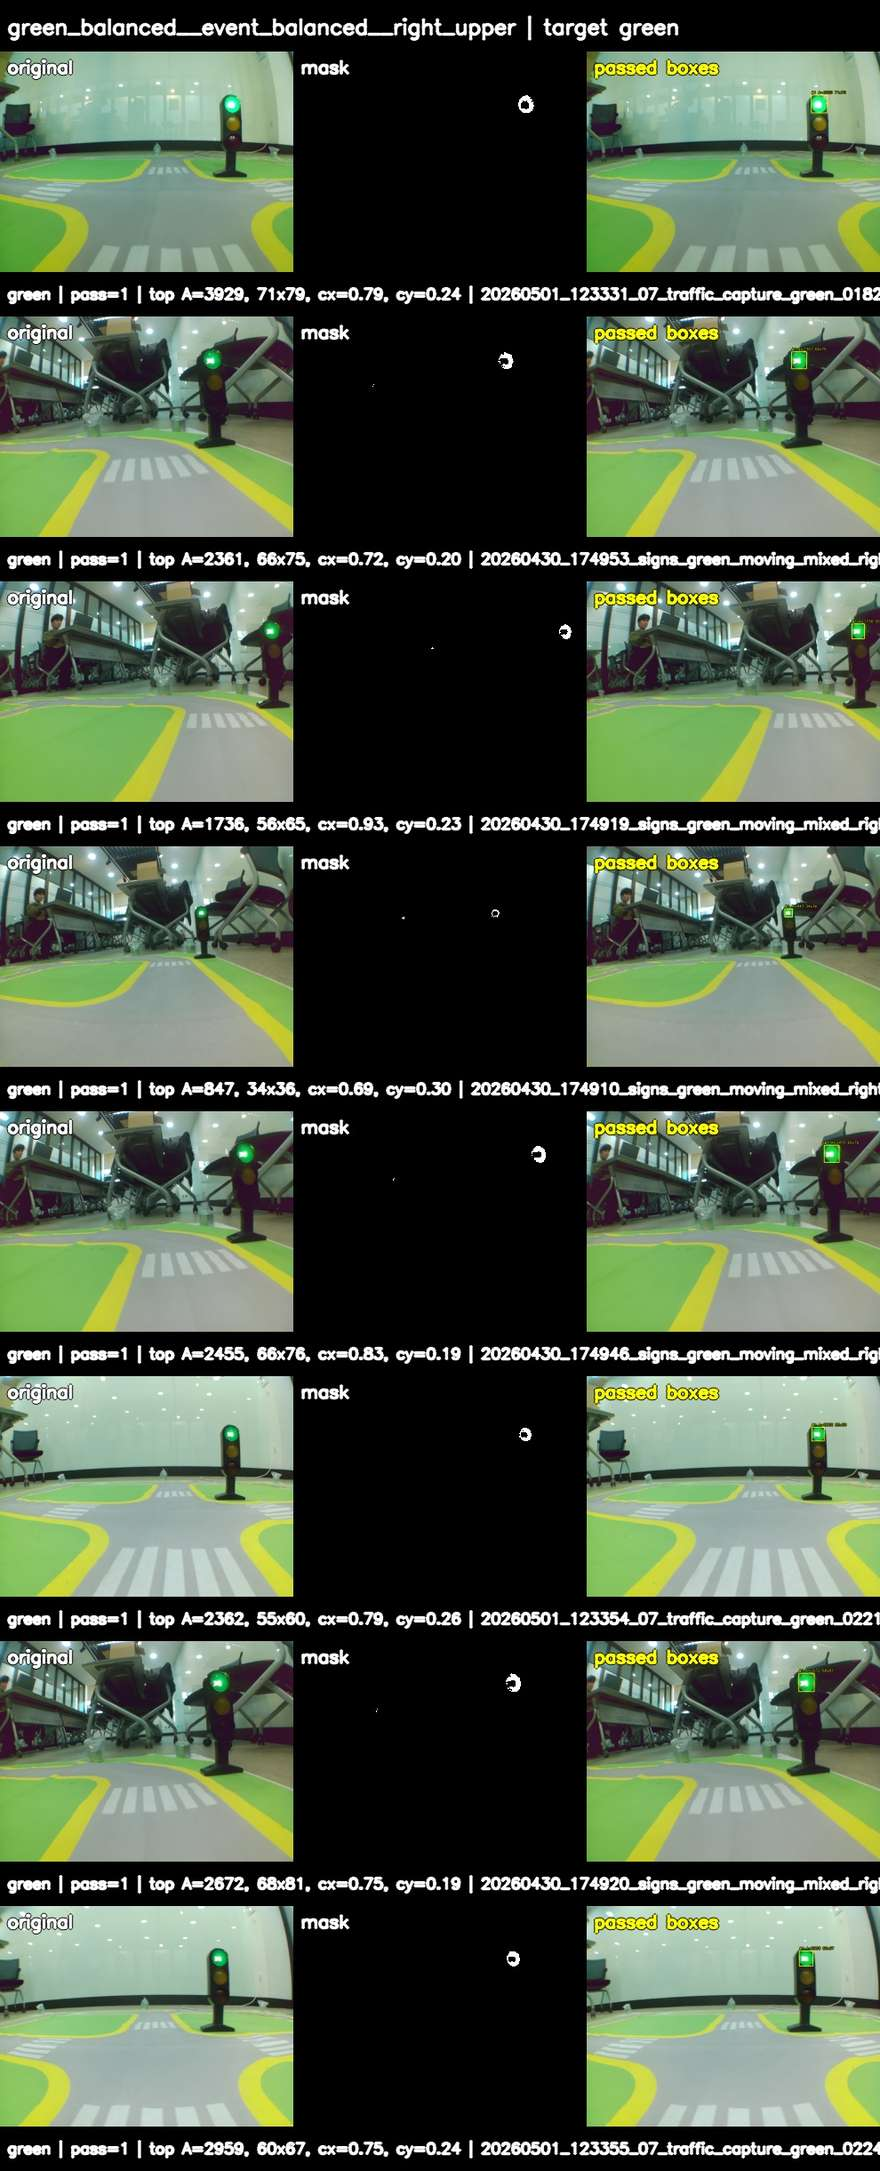

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_balanced__event_balanced__right_upper__cross_sheet.jpg


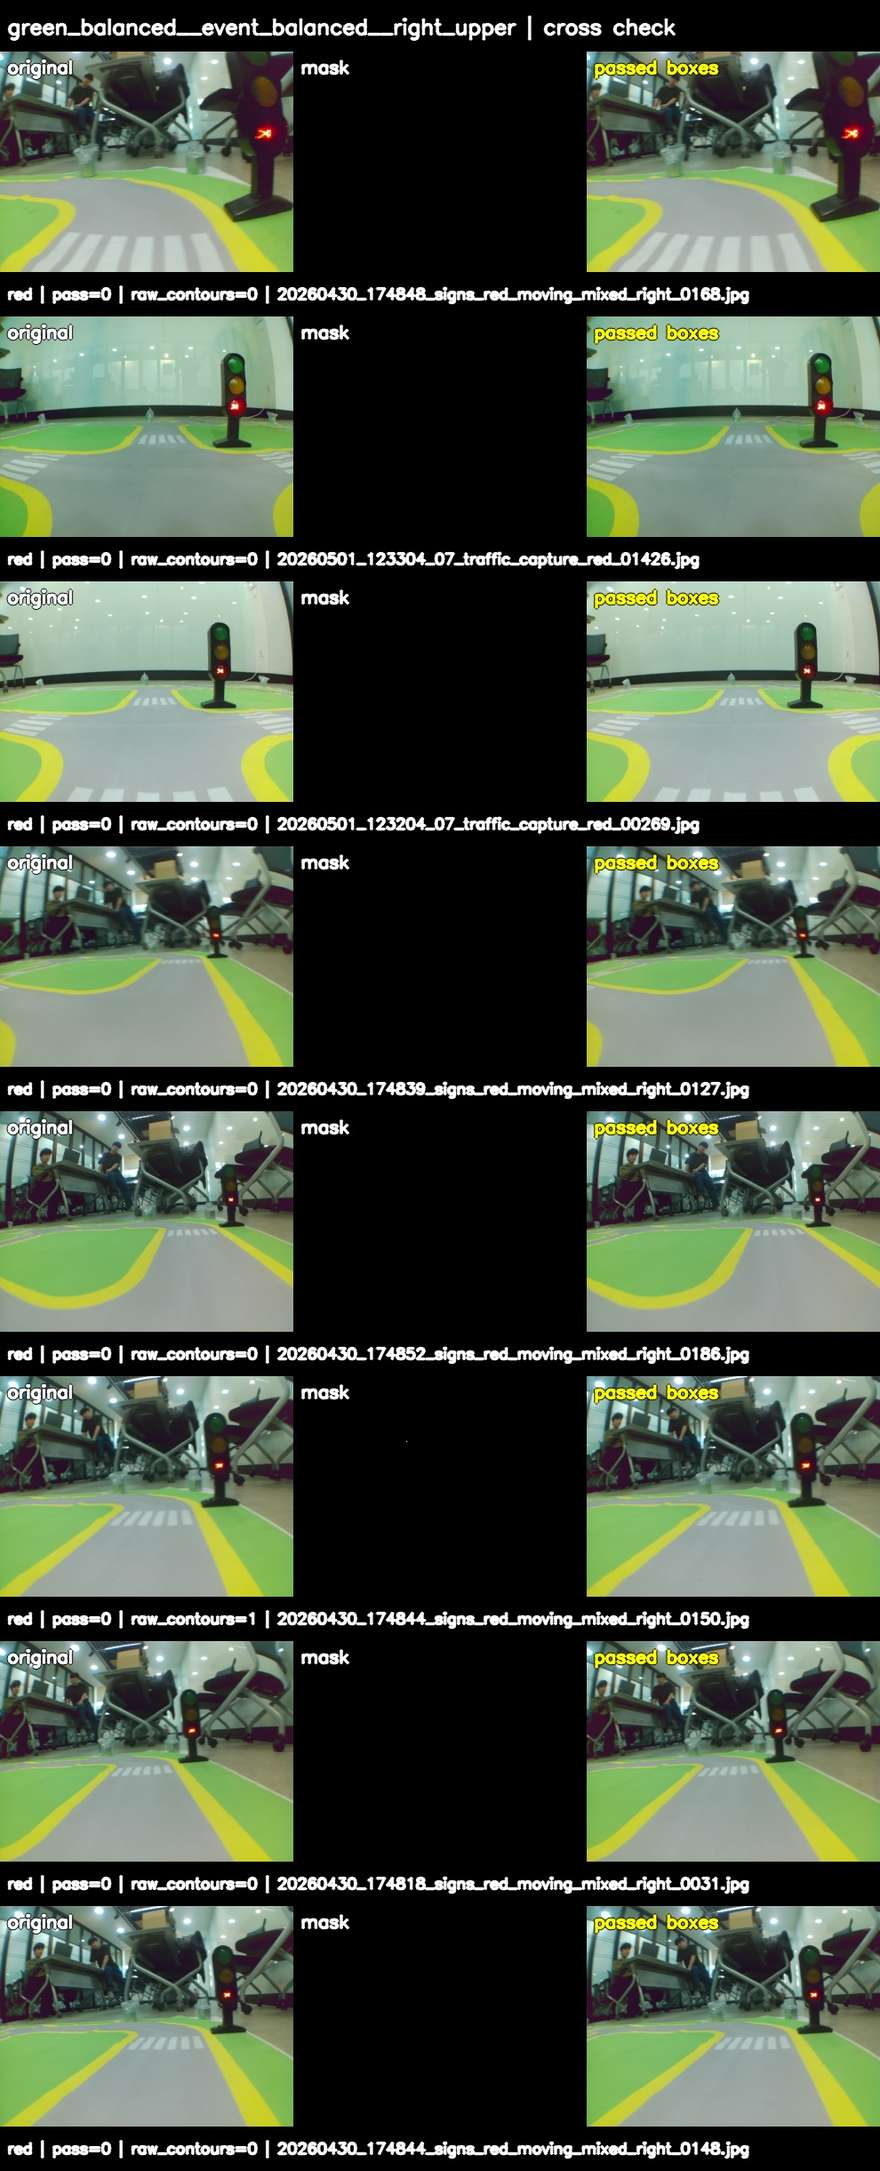

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_strict__event_balanced__right_upper__target_sheet.jpg


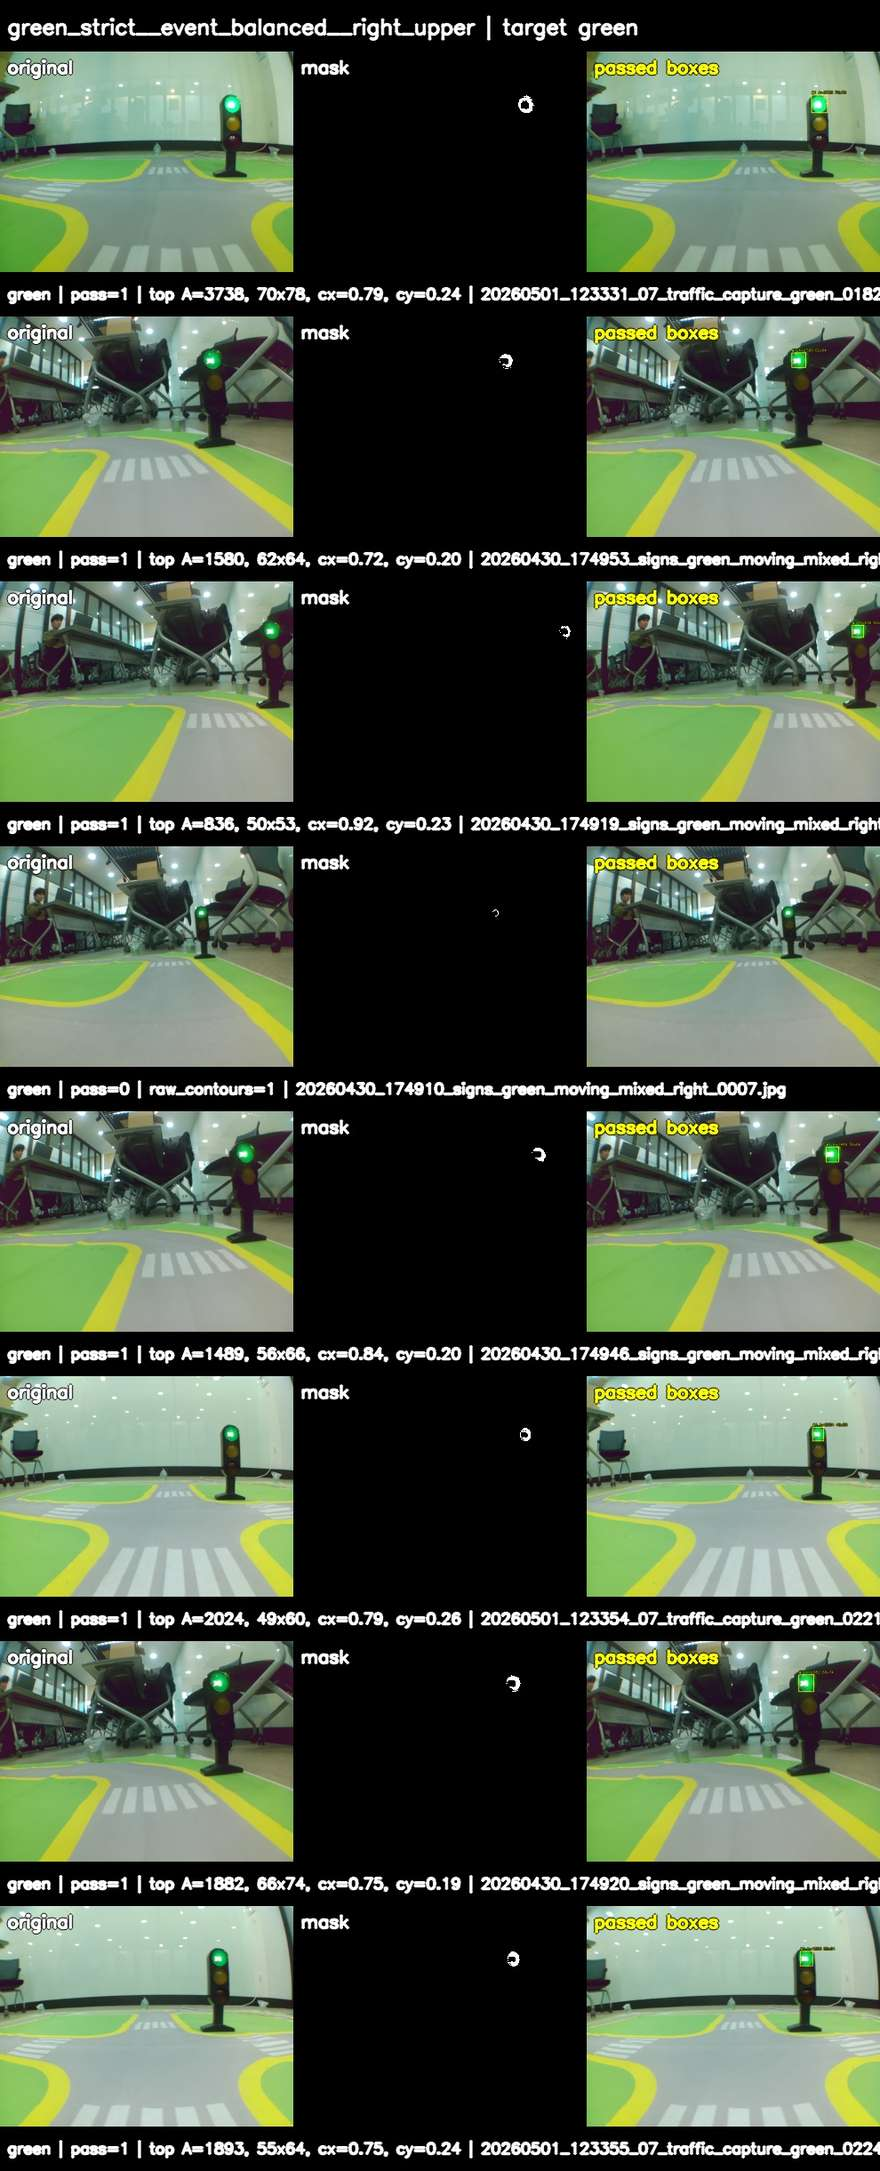

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_strict__event_balanced__right_upper__cross_sheet.jpg


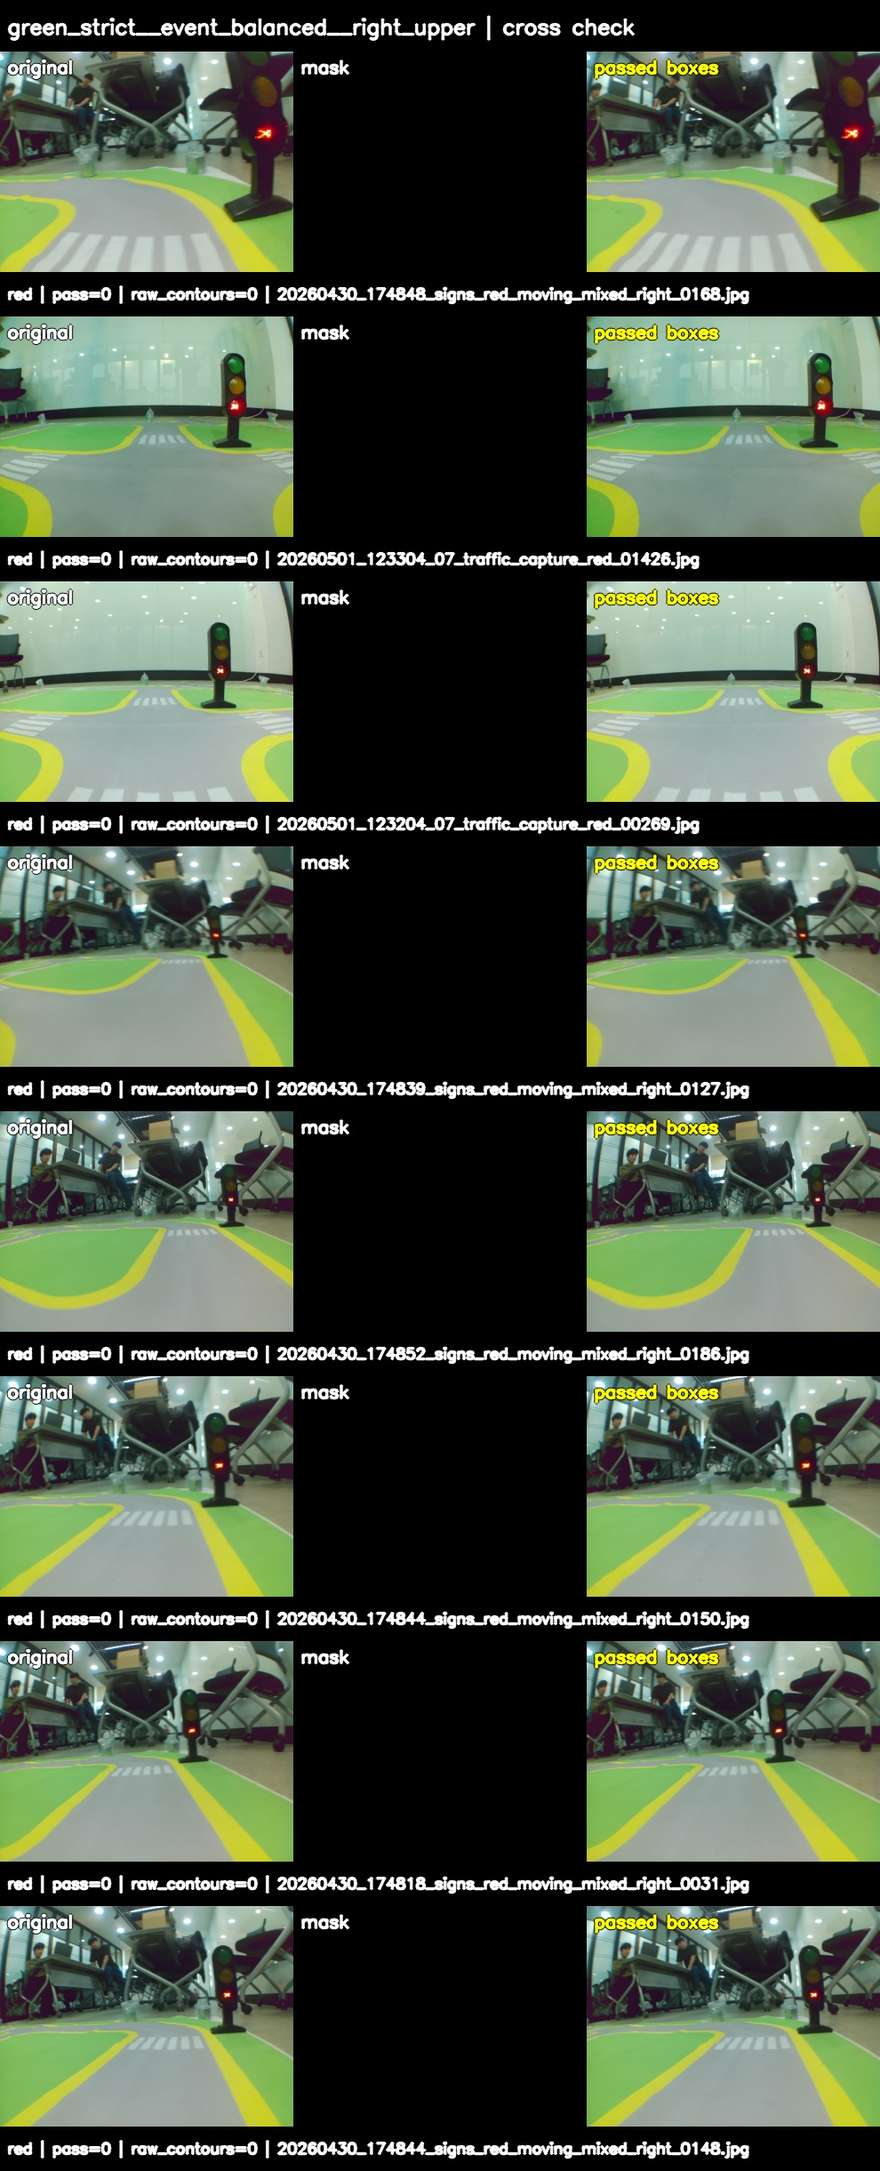

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_balanced__near_event_strict__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\green_balanced__near_event_strict__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_balanced__event_balanced__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_balanced__event_balanced__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_strict__event_balanced__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_strict__event_balanced__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_balanced__near_event_strict__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\red_balanced__near_event_strict__right_upper__cross_sheet.jpg


In [11]:
VISUAL_PROFILES = [
    ("green_balanced", "event_balanced", "right_upper"),
    ("green_strict", "event_balanced", "right_upper"),
    ("green_balanced", "near_event_strict", "right_upper"),
    ("red_balanced", "event_balanced", "right_upper"),
    ("red_strict", "event_balanced", "right_upper"),
    ("red_balanced", "near_event_strict", "right_upper"),
]

vis_green = vis_df[vis_df["label"] == "green"].to_dict("records")
vis_red = vis_df[vis_df["label"] == "red"].to_dict("records")
visual_sheet_paths = []

for cp_name, cf_name, sg_name in VISUAL_PROFILES:
    target = get_profile_by_name(cp_name)["target"]
    target_records = vis_green if target == "green" else vis_red
    cross_records = vis_red if target == "green" else vis_green
    stem = f"{cp_name}__{cf_name}__{sg_name}"
    out_target = OVERLAY_DIR / f"{stem}__target_sheet.jpg"
    out_cross = OVERLAY_DIR / f"{stem}__cross_sheet.jpg"
    make_detector_sheet(cp_name, cf_name, sg_name, target_records, out_target, f"{stem} | target {target}")
    make_detector_sheet(cp_name, cf_name, sg_name, cross_records, out_cross, f"{stem} | cross check")
    visual_sheet_paths.extend([out_target, out_cross])

for path in visual_sheet_paths:
    print(path)
    show_saved_image(path, width=980)

## manual stress overlay

사용자가 직접 지목했던 저조도/스트레스 샘플에서도 detector candidate를 본다.

stress records: {'green': 8, 'red': 8}
~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_balanced__event_balanced__right_upper__target_sheet.jpg


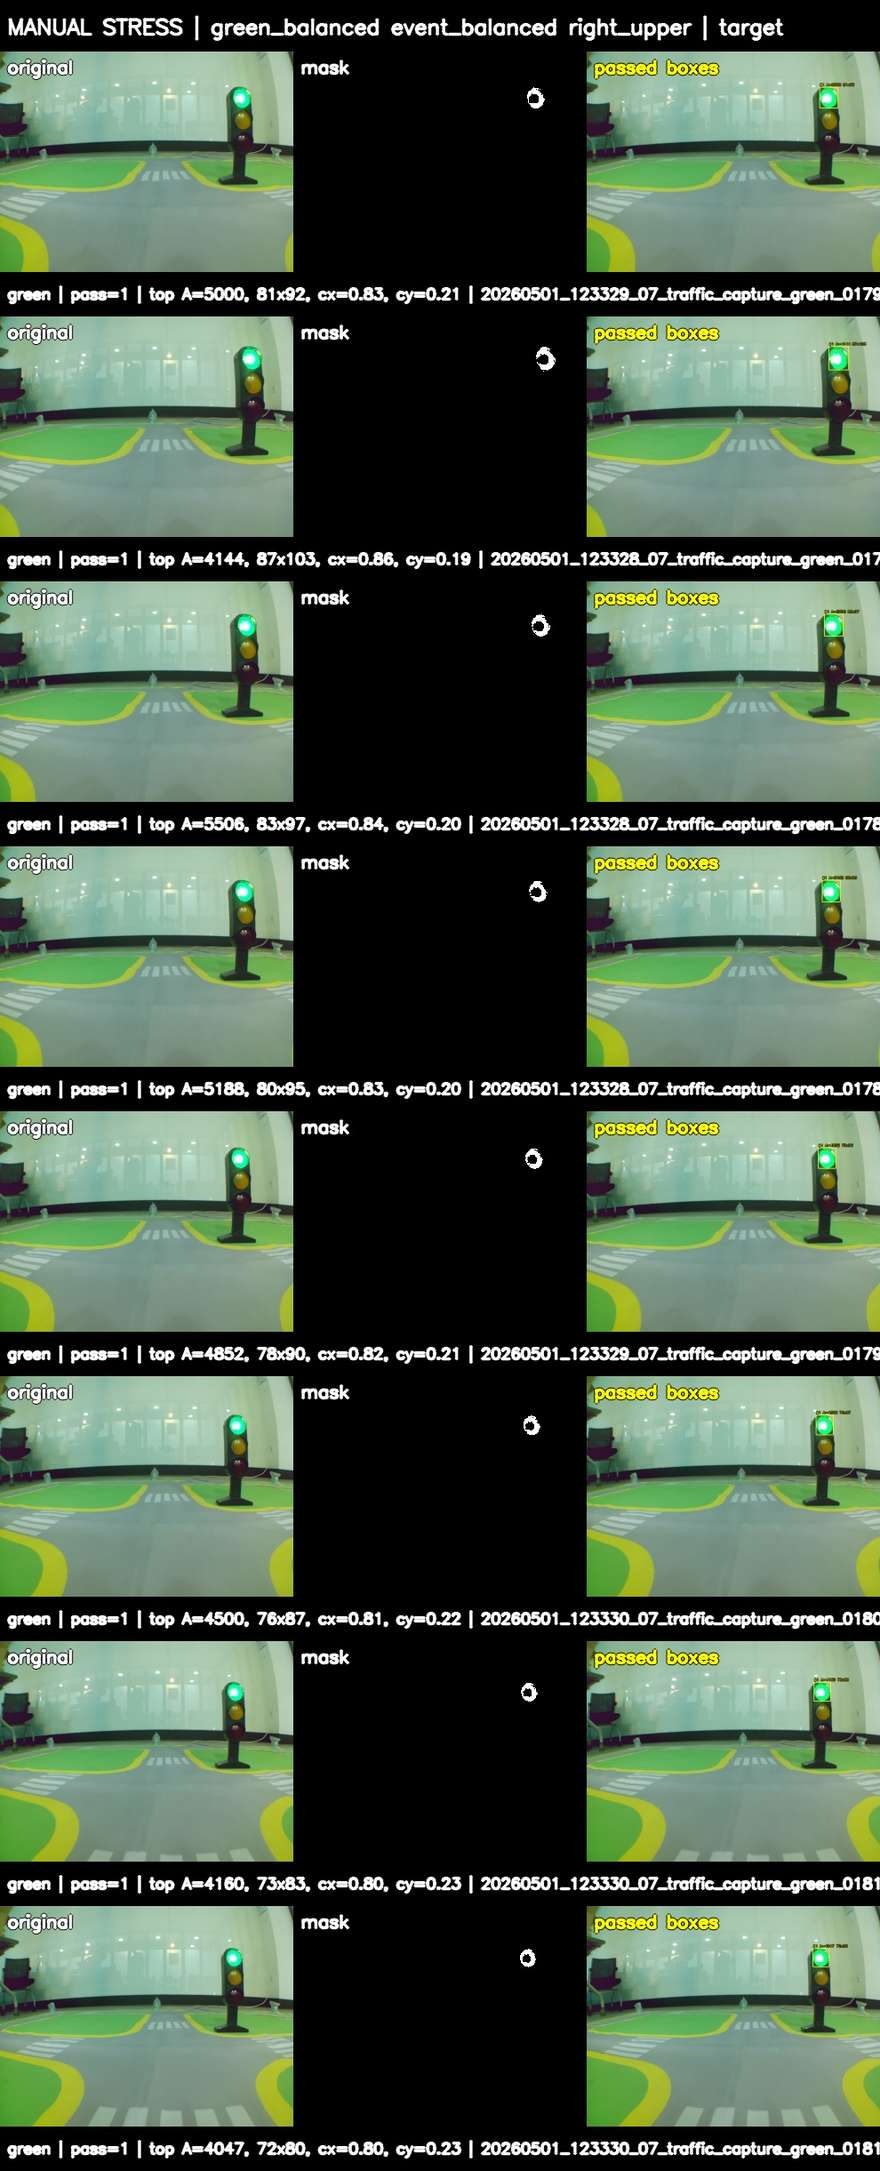

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_balanced__event_balanced__right_upper__cross_sheet.jpg


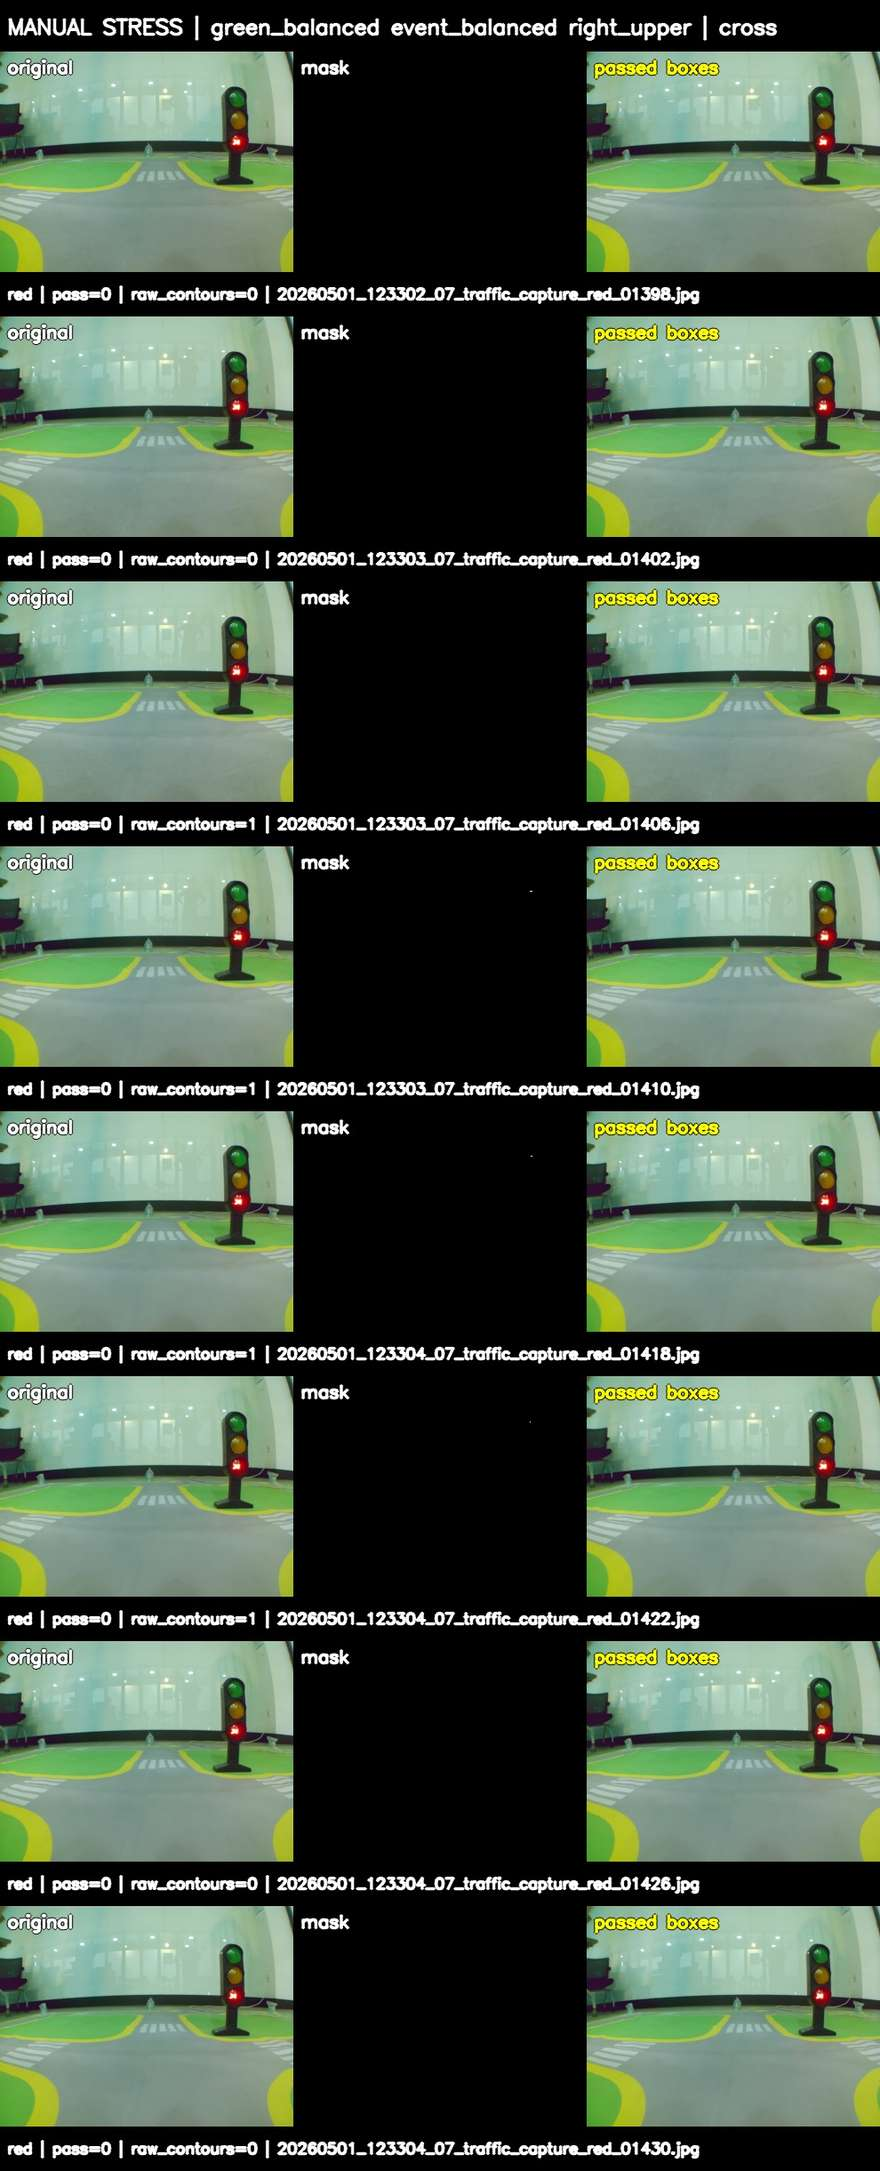

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_strict__event_balanced__right_upper__target_sheet.jpg


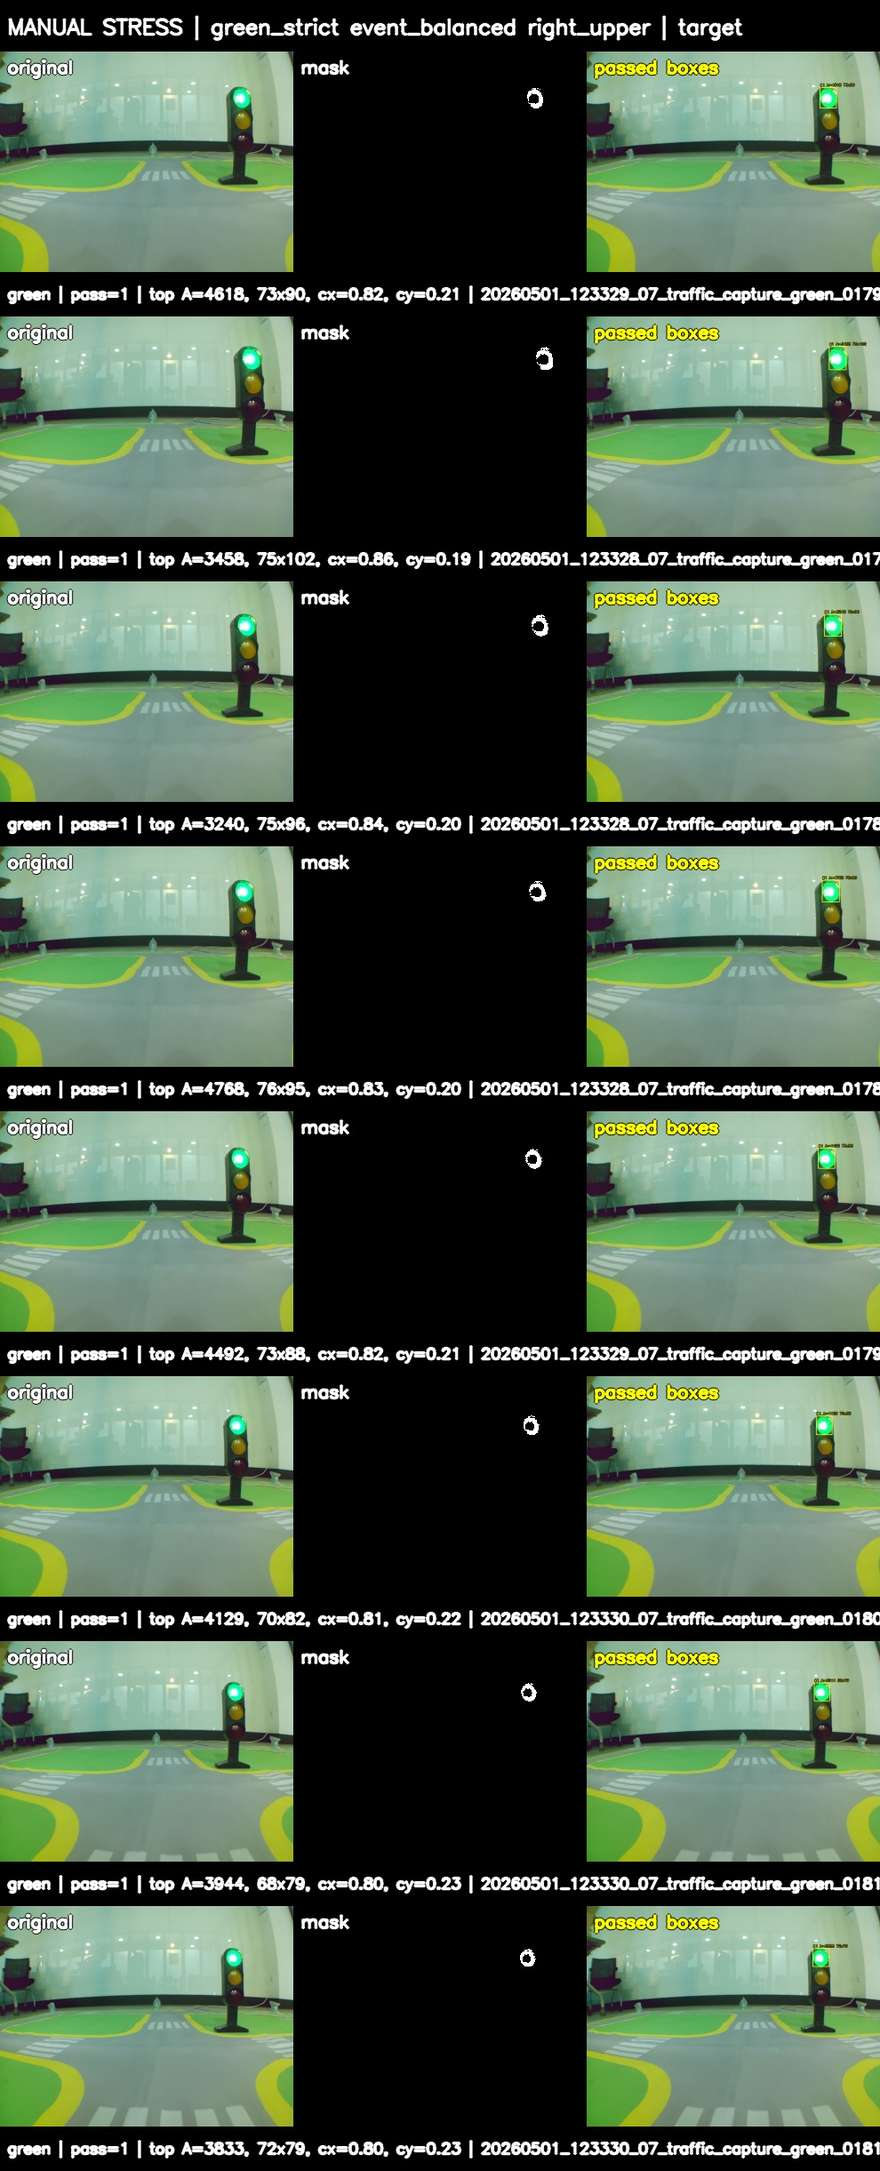

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_strict__event_balanced__right_upper__cross_sheet.jpg


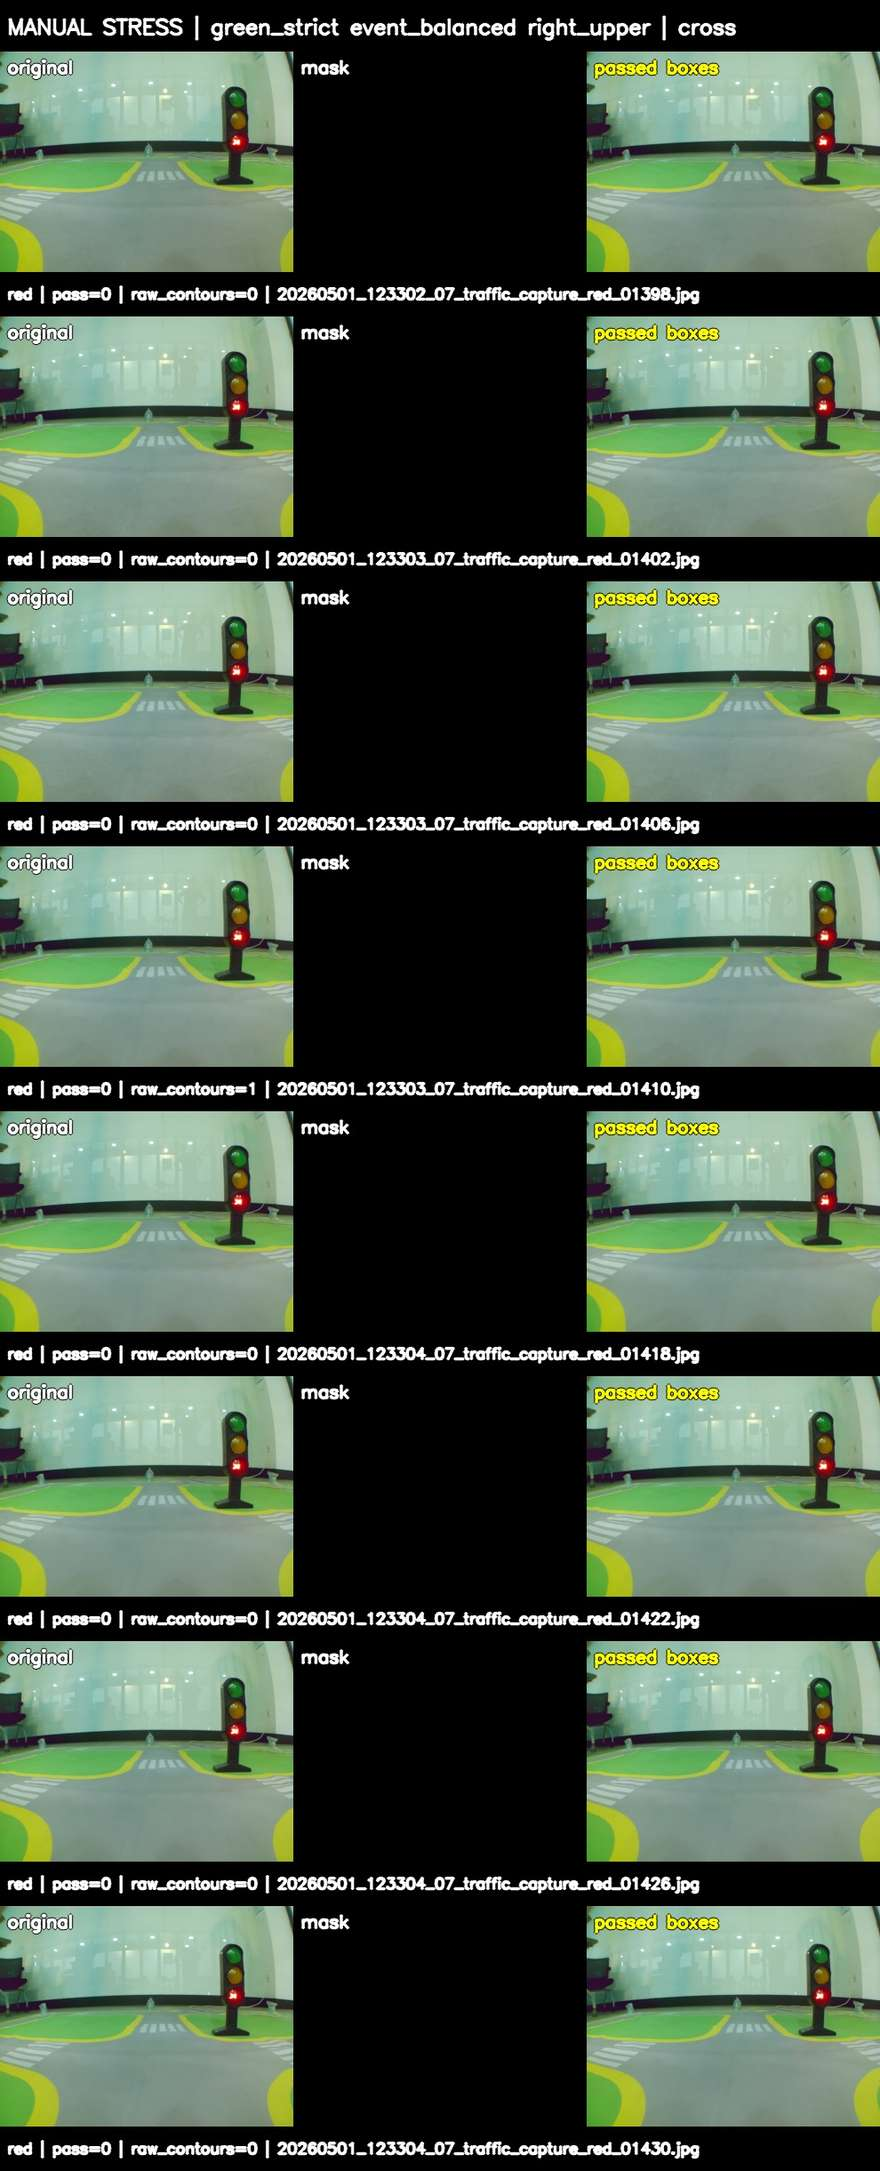

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_balanced__near_event_strict__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__green_balanced__near_event_strict__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_balanced__event_balanced__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_balanced__event_balanced__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_strict__event_balanced__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_strict__event_balanced__right_upper__cross_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_balanced__near_event_strict__right_upper__target_sheet.jpg


~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\overlays\manual_stress__red_balanced__near_event_strict__right_upper__cross_sheet.jpg


In [12]:
stress_sheet_paths = []
if len(stress_df):
    stress_green = stress_df[stress_df["label"] == "green"].to_dict("records")
    stress_red = stress_df[stress_df["label"] == "red"].to_dict("records")
    print("stress records:", {"green": len(stress_green), "red": len(stress_red)})
    for cp_name, cf_name, sg_name in VISUAL_PROFILES:
        target = get_profile_by_name(cp_name)["target"]
        target_records = stress_green if target == "green" else stress_red
        cross_records = stress_red if target == "green" else stress_green
        stem = f"manual_stress__{cp_name}__{cf_name}__{sg_name}"
        out_target = OVERLAY_DIR / f"{stem}__target_sheet.jpg"
        out_cross = OVERLAY_DIR / f"{stem}__cross_sheet.jpg"
        made_target = make_detector_sheet(cp_name, cf_name, sg_name, target_records, out_target, f"MANUAL STRESS | {cp_name} {cf_name} {sg_name} | target")
        made_cross = make_detector_sheet(cp_name, cf_name, sg_name, cross_records, out_cross, f"MANUAL STRESS | {cp_name} {cf_name} {sg_name} | cross")
        for made in [made_target, made_cross]:
            if made is not None and exists_fs(made):
                stress_sheet_paths.append(made)
            else:
                print("skip missing stress sheet:", made)
else:
    print("No manual stress dataframe available.")

for path in stress_sheet_paths:
    print(path)
    show_saved_image(path, width=980)


## 후보를 읽는 기준

01c 결과를 볼 때는 아래 기준으로 판단한다.

1. `event_balanced + right_upper`에서 target hit이 충분한가?
2. cross hit이 0에 가까운가?
3. `near_event_strict`가 놓치는 프레임은 정말 멀거나 이벤트 전이라고 봐도 되는가?
4. green/red의 size threshold를 분리하는 게 타당한가?
5. right/upper gate를 넣었을 때 실제 신호등을 놓치지 않는가?

이 질문에 답하고 나서야 01d 또는 contract 후보로 넘어갈 수 있다.

In [13]:
notes = "\n".join([
    "# 01c Traffic Detector Candidate Notes",
    "",
    "## Purpose",
    "",
    "Compare detector candidates made from color profile + contour filter + loose spatial gate.",
    "This is not a final contract.",
    "",
    "## Outputs",
    "",
    "- traffic_detector_candidate_frame_results.csv",
    "- traffic_detector_candidate_passed_contours.csv",
    "- traffic_detector_candidate_summary.csv",
    "- heatmaps for target/cross hit percentage",
    "- overlay sheets for selected profiles",
    "",
    "## Manual review questions",
    "",
    "1. Does event_balanced + right_upper keep true traffic light candidates?",
    "2. Does it remove cross-color candidates?",
    "3. Does near_event_strict only remove far/non-event frames?",
    "4. Are green/red thresholds clearly different?",
    "5. Should the next notebook add temporal voting, or should redline work start first?",
])
notes_path = NOTES_DIR / "01c_traffic_detector_candidate_notes.md"
notes_path.write_text(notes, encoding="utf-8")
print(notes_path)

~\02_Projects\University\26-1_EmbeddedArtificialSystemOptimization\10_experiments\18_opencv_color_event_detector\review_outputs\01c_traffic_detector_candidate_v1\notes\01c_traffic_detector_candidate_notes.md


## 다음 단계

결과에 따라 다음 중 하나로 간다.

```text
A. traffic detector 후보가 충분히 좋아 보임
   → 01d에서 temporal voting / event trigger mock 실험

B. 색/contour는 좋지만 spatial gate 조정 필요
   → 01c를 조금 확장해서 gate 후보만 더 비교

C. traffic은 충분히 방향이 잡힘
   → 02_redline_color_probe_v1로 이동
```

아직 최종 contract는 만들지 않는다.